# Notebook 4 - Beyond the Surface Code: qLDPC & Bivariate-Bicycle Codes

*Part of **QEC Explorer**. Notebooks 1-3 built the surface code and showed both its power and its costs: it needs **large distances** for clean protection, and large distance means **a lot of physical qubits per logical qubit.** This notebook asks the natural next question - can we do better? - and answers it with the class of codes that currently looks most promising: **quantum low-density parity-check (qLDPC) codes**, and IBM's **bivariate-bicycle (BB)** family in particular.*

The plan:
1. Put **real numbers** on the surface code's overhead problem.
2. Introduce the bivariate-bicycle construction and its **~10x overhead improvement**.
3. Draw the **Tanner graphs** so you can *see* why these codes are different.
4. Then the spin-off payoff: **actually build IBM's [[144,12,12]] "gross code"** from its two polynomials, verify the CSS condition and count the logical qubits ourselves, and **decode it with BP+OSD** - the decoder class real qLDPC proposals use.

> ### Built on ldpc (Joschka Roffe)
> This is a QEC Explorer spin-off notebook. Sections 4-5 use **[ldpc](https://github.com/quantumgizmos/ldpc)** (Joschka Roffe, MIT license), the standard open-source Python package for belief-propagation and **BP+OSD** decoding of quantum LDPC codes. We build the check matrices ourselves from the published polynomials; `ldpc` supplies the GF(2) linear algebra and the production-grade decoder.

> ### Same code, live
> The **Module 4 - qLDPC Explorer** runs an interactive gross-code simulation in your browser:
> **-> [QEC Explorer - Module 4 (live)](https://qecexplorer.com/qldpc)**

---
## 1 - The surface code's overhead problem (with real numbers)

The surface code is wonderful in one respect - it's *local* (every check touches only neighboring qubits on a 2D grid) and has a high threshold (~1%, and we measured it ourselves in Notebook 3). But it pays for that locality with **qubit overhead**.

A distance-$d$ rotated surface code (the one we built) uses $d^2$ data qubits to protect **one** logical qubit, plus a comparable number of ancilla (measurement) qubits. To reach the low logical error rates a real algorithm needs, you need fairly large $d$:

- At $d = 3$: 9 data qubits per logical qubit (what our tools simulate).
- At $d = 25$ (a distance discussed for useful machines): $25^2 = 625$ data qubits per logical qubit, and roughly **double** that once ancillas are counted.

Published estimates for *running real algorithms* (where you need many logical qubits each at very low error rate) put the surface-code cost on the order of **~1,000 physical qubits per logical qubit** - this specific round figure is **illustrative** of the commonly-cited scale, not a single sourced constant, because the exact number depends on the target error rate and architecture. The *structural* fact is solid and citable: surface-code overhead grows like $d^2$ and that becomes the dominant cost at scale.

ldpc 2.4.1 ready (BP and BP+OSD decoders + GF(2) linear algebra).


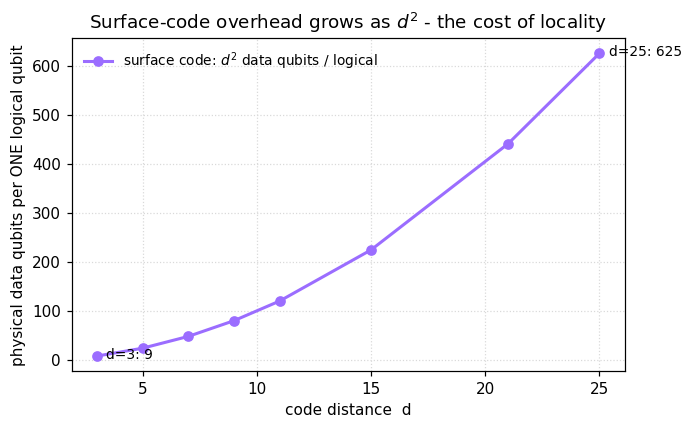

Exact (rotated surface code): one logical qubit costs d^2 data qubits + ~d^2 ancillas.
At d=25 that's 625 data qubits for a SINGLE logical qubit - before ancillas.


In [1]:
# Colab / fresh-environment setup. Safe to re-run.
try:
    import ldpc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ldpc"], check=True)
    import ldpc

import numpy as np
import matplotlib.pyplot as plt
from ldpc import BpDecoder, BpOsdDecoder
import ldpc.mod2 as mod2

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
print(f"ldpc {ldpc.__version__} ready (BP and BP+OSD decoders + GF(2) linear algebra).")

# Surface-code data-qubit overhead vs distance (structural, exact for the rotated code)
dists = np.array([3, 5, 7, 9, 11, 15, 21, 25])
data_qubits = dists**2  # rotated surface code: d^2 data qubits per logical qubit

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(dists, data_qubits, "o-", color="#9b6dff", lw=2, label="surface code: $d^2$ data qubits / logical")
for d, n in zip(dists, data_qubits):
    if d in (3, 25): ax.annotate(f"d={d}: {n}", (d, n), textcoords="offset points", xytext=(6, -2), fontsize=9)
ax.set_xlabel("code distance  d"); ax.set_ylabel("physical data qubits per ONE logical qubit")
ax.set_title("Surface-code overhead grows as $d^2$ - the cost of locality")
ax.grid(True, ls=":", color="0.85"); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print("Exact (rotated surface code): one logical qubit costs d^2 data qubits + ~d^2 ancillas.")
print("At d=25 that's 625 data qubits for a SINGLE logical qubit - before ancillas.")

---
## 2 - qLDPC codes, and the bivariate-bicycle idea

A **quantum low-density parity-check (qLDPC)** code keeps the good property that every check involves only a *few* qubits (low density / bounded weight), but **drops the requirement that those qubits be geometric neighbors on a 2D grid.** By allowing a small number of *longer-range* connections, qLDPC codes can encode **many logical qubits in far fewer physical qubits** than the surface code.

IBM's **bivariate-bicycle (BB)** codes are the headline example. The construction (Bravyi et al., *Nature* 2024) builds the X- and Z-check matrices from **two bivariate polynomials** over a cyclic group $\mathbb{Z}_\ell \times \mathbb{Z}_m$ - hence "bivariate," and "bicycle" because the check matrix is built from two circulant blocks. The key structural facts, all citable *and all verified by us in Section 4*:

- **Every check has weight 6** (touches exactly 6 qubits) - still low-density, like the surface code's weight-4 checks.
- **Each qubit connects to 6 checks** (3 X-checks and 3 Z-checks), and the connectivity graph **decomposes into two planar (degree-3) layers** - so it's *almost* 2D-local, just with a couple of longer-range links. That "almost local" is what makes it buildable on real hardware.
- The flagship **[[144, 12, 12]] "gross code"**: **144 data qubits + 144 ancilla = 288 physical qubits**, encoding **12 logical qubits**, at **distance 12**.

Compare the overhead. A surface code at distance 12 protects **one** logical qubit with ~$12^2 = 144$ data qubits. The gross code protects **twelve** logical qubits at the same distance with the same 144 data qubits - a **~10-12x improvement in encoding rate**, which is the figure IBM reports.

In [2]:
# Encoding-rate comparison (sourced parameters):
#   surface code at distance d: [[~d^2, 1, d]]  -> 1 logical per d^2 data qubits
#   gross BB code:              [[144, 12, 12]] -> 12 logical per 144 data qubits
def surface_params(d): return dict(n=d*d, k=1, d=d, rate=1/(d*d))
gross_params = dict(n=144, k=12, d=12, rate=12/144)

sc12 = surface_params(12)
print("Surface code, distance 12:   [[%d, %d, %d]]  encoding rate k/n = %.4f"
      % (sc12["n"], sc12["k"], sc12["d"], sc12["rate"]))
print("Gross BB code (IBM, Nature): [[%d, %d, %d]]  encoding rate k/n = %.4f"
      % (gross_params["n"], gross_params["k"], gross_params["d"], gross_params["rate"]))
print("\nSame data-qubit count (144), same distance (12):")
print("  surface code protects %d logical qubit;  gross code protects %d." % (sc12["k"], gross_params["k"]))
print("  -> ~%.0fx higher encoding rate for the BB code (IBM reports ~10x overhead reduction)."
      % (gross_params["rate"]/sc12["rate"]))

Surface code, distance 12:   [[144, 1, 12]]  encoding rate k/n = 0.0069
Gross BB code (IBM, Nature): [[144, 12, 12]]  encoding rate k/n = 0.0833

Same data-qubit count (144), same distance (12):
  surface code protects 1 logical qubit;  gross code protects 12.
  -> ~12x higher encoding rate for the BB code (IBM reports ~10x overhead reduction).


---
## 3 - Seeing the difference: Tanner graphs

The clearest way to *feel* why these codes differ is to look at their **Tanner graphs** - the bipartite graph linking data qubits to the checks that touch them.

- **Surface code:** checks are **geometrically local**. Every check links to at most 4 data qubits that are its immediate neighbors on the grid. Draw it and you get a clean, planar, grid-like graph - no long edges.
- **Bivariate-bicycle code:** checks have weight 6 and the connectivity is **two planar layers plus a few longer-range links**. Draw it and you see mostly-local structure *with* some edges that jump across the layout - exactly the "almost local" character that buys the higher rate.

Below we draw the **real** surface-code Tanner graph (from the code we built in Notebook 1), then a **small, explicitly-simplified** bicycle-style graph built from two circulant shifts to illustrate the *contrast in connectivity*.

> **What's simplified:** the right-hand graph is a *toy* circulant structure for visual intuition only - it is not the [[144,12,12]] code (that one has 144 + 144 nodes, far too dense to read as a picture). The **real** gross code, with the CSS condition verified and the logical qubits counted, is built in the very next section.

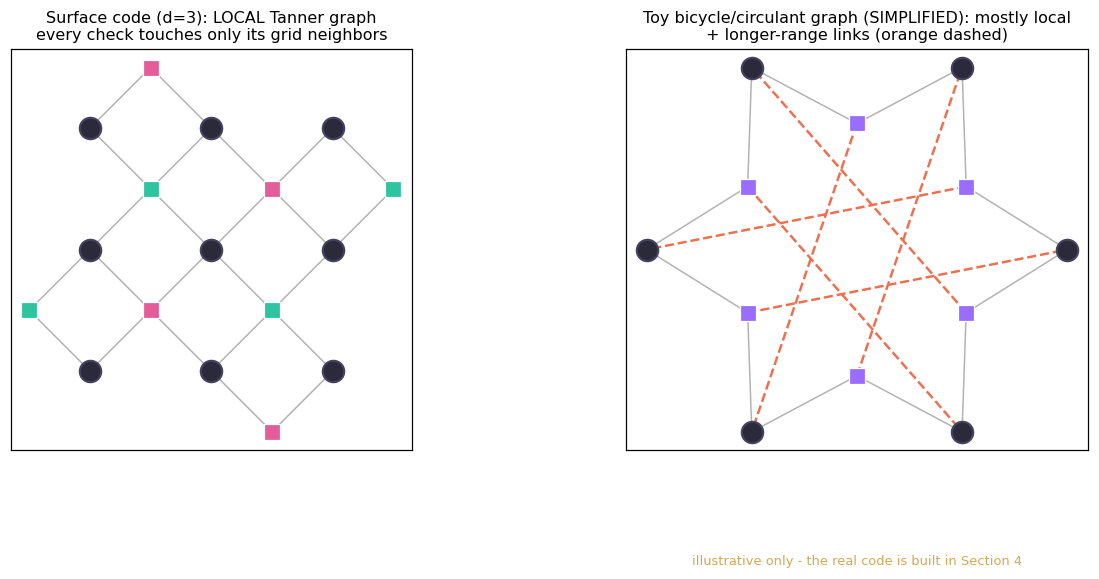

Left: real surface-code Tanner graph (all edges short/local).
Right: toy circulant structure - note the orange long-range edges qLDPC codes add.


In [3]:
# ---- real surface-code Tanner graph (reuse Notebook 1's build, condensed) ----
def build_data_qubits(d): return [(r,c) for r in range(d) for c in range(d)]
def build_stabilizers(d):
    stabs=[]
    for R in range(-1,d):
        for C in range(-1,d):
            t="Z" if (R+C)%2==0 else "X"
            cand=[(rr,cc) for (rr,cc) in [(R,C),(R,C+1),(R+1,C),(R+1,C+1)] if 0<=rr<d and 0<=cc<d]
            if not cand: continue
            tb=(R==-1 or R==d-1); lr=(C==-1 or C==d-1)
            if len(cand)==2:
                if t=="Z" and not lr: continue
                if t=="X" and not tb: continue
            if len(cand) not in (2,4): continue
            stabs.append({"type":t,"center":(C+0.5,R+0.5),"data":cand})
    return stabs

d=3
data=build_data_qubits(d); stabs=build_stabilizers(d)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))

# LEFT: surface code Tanner graph, drawn on its real geometry
ax=axes[0]
for s in stabs:
    cx,cy=s["center"]
    for (r,c) in s["data"]:
        ax.plot([c,cx],[r,cy], color="0.7", lw=1, zorder=1)
for (r,c) in data:
    ax.plot(c,r,"o",ms=14,color="#2a2a3a",mec="#43435f",mew=1.4,zorder=3)
for s in stabs:
    cx,cy=s["center"]
    col="#2ec4a0" if s["type"]=="Z" else "#e45d9a"
    ax.plot(cx,cy,"s",ms=11,color=col,mec="white",mew=0.8,zorder=3)
ax.set_aspect("equal"); ax.invert_yaxis()
ax.set_title("Surface code (d=3): LOCAL Tanner graph\nevery check touches only its grid neighbors", fontsize=10.5)
ax.set_xticks([]); ax.set_yticks([])

# RIGHT: toy bicycle/circulant Tanner graph (SIMPLIFIED, for contrast only)
ax=axes[1]
L=6  # toy ring size
theta=np.linspace(0,2*np.pi,L,endpoint=False)
qx,qy=np.cos(theta),np.sin(theta)              # data qubits on a ring
cx_,cy_=0.6*np.cos(theta+np.pi/L),0.6*np.sin(theta+np.pi/L)  # checks inside
# two circulant shifts: each check i connects to data i, i+1 (local) and i+3 (long-range wrap)
shifts=[0,1,3]
for i in range(L):
    for sh in shifts:
        j=(i+sh)%L
        long_range = sh==3
        ax.plot([cx_[i],qx[j]],[cy_[i],qy[j]],
                color=("#ef6e4e" if long_range else "0.7"),
                lw=(1.6 if long_range else 1),
                ls=("--" if long_range else "-"), zorder=1)
for i in range(L):
    ax.plot(qx[i],qy[i],"o",ms=14,color="#2a2a3a",mec="#43435f",mew=1.4,zorder=3)
    ax.plot(cx_[i],cy_[i],"s",ms=11,color="#9b6dff",mec="white",mew=0.8,zorder=3)
ax.set_aspect("equal")
ax.set_title("Toy bicycle/circulant graph (SIMPLIFIED): mostly local\n+ longer-range links (orange dashed)", fontsize=10.5)
ax.set_xticks([]); ax.set_yticks([])
ax.text(0,-1.5,"illustrative only - the real code is built in Section 4", ha="center", fontsize=8.5, color="#d4a855")

plt.tight_layout(); plt.show()
print("Left: real surface-code Tanner graph (all edges short/local).")
print("Right: toy circulant structure - note the orange long-range edges qLDPC codes add.")

The contrast is the whole point. The surface code's graph is **all short edges** - beautifully local, but that locality is exactly what forces the $d^2$ overhead. The bicycle-style graph keeps *most* edges local but adds a **few long-range links** (orange, dashed), and those few non-local connections are what let it pack many more logical qubits into the same number of physical ones.

The price: those long-range links are **harder to build** in hardware (you can't just wire nearest neighbors), and they make **decoding harder** - which connects directly to why BP+OSD (this notebook) and learned decoders (Notebook 5) matter for these codes.

---
## 4 - Building the real gross code (the spin-off payoff)

An earlier version of this notebook stopped at the toy picture and honestly listed what a real implementation would need: choose the two polynomials so the X- and Z-checks **commute** (the CSS condition $H_X H_Z^T = 0$), and **count the logical qubits** from the check-matrix ranks. Now we do those things, for the actual published code.

The recipe from Bravyi et al. (*Nature* 2024). Take $\ell = 12$, $m = 6$, and the two monomial matrices $x = S_\ell \otimes I_m$ and $y = I_\ell \otimes S_m$, where $S_n$ is the cyclic shift on $n$ elements. The gross code's two polynomials are:

$$A = x^3 + y + y^2 \qquad B = y^3 + x + x^2$$

and the check matrices are the two circulant blocks glued side by side:

$$H_X = [\,A \mid B\,] \qquad H_Z = [\,B^T \mid A^T\,]$$

That gives $n = 2 \ell m = 144$ data qubits. Because $A$ and $B$ are polynomials in the same commuting matrices $x$ and $y$, we get $AB = BA$, which makes $H_X H_Z^T = AB + BA = 0$ over GF(2) - the CSS condition, for free. The number of logical qubits is then pure linear algebra:

$$k = n - \mathrm{rank}(H_X) - \mathrm{rank}(H_Z)$$

We verify every one of those claims by direct computation, using `ldpc.mod2` for GF(2) rank.

In [4]:
def cyclic_shift(n):
    S = np.zeros((n, n), dtype=np.uint8)
    for i in range(n):
        S[i, (i + 1) % n] = 1
    return S

def bb_code(l, m, a_terms, b_terms):
    # Bivariate-bicycle code from polynomial terms.
    # Each term (i, j) means x^i y^j, with x = S_l kron I_m and y = I_l kron S_m.
    Sl, Sm = cyclic_shift(l), cyclic_shift(m)
    Il, Im = np.eye(l, dtype=np.uint8), np.eye(m, dtype=np.uint8)
    x, y = np.kron(Sl, Im), np.kron(Il, Sm)
    def poly(terms):
        M = np.zeros((l * m, l * m), dtype=np.uint8)
        for (i, j) in terms:
            M ^= (np.linalg.matrix_power(x, i) @ np.linalg.matrix_power(y, j) % 2).astype(np.uint8)
        return M
    A, B = poly(a_terms), poly(b_terms)
    HX = np.hstack([A, B]).astype(np.uint8) % 2
    HZ = np.hstack([B.T, A.T]).astype(np.uint8) % 2
    return HX, HZ

# The gross code: l=12, m=6, A = x^3 + y + y^2, B = y^3 + x + x^2
HX, HZ = bb_code(12, 6, [(3, 0), (0, 1), (0, 2)], [(0, 3), (1, 0), (2, 0)])
n = HX.shape[1]

css_ok = not np.any(HX @ HZ.T % 2)
rank_HX, rank_HZ = mod2.rank(HX), mod2.rank(HZ)
k = n - rank_HX - rank_HZ
row_weights = set(HX.sum(axis=1).tolist()) | set(HZ.sum(axis=1).tolist())
col_deg_X = set(HX.sum(axis=0).tolist()); col_deg_Z = set(HZ.sum(axis=0).tolist())

print(f"n (data qubits)         : {n}")
print(f"CSS condition HX HZ^T=0 : {css_ok}")
print(f"rank(HX), rank(HZ)      : {rank_HX}, {rank_HZ}")
print(f"k = n - rankHX - rankHZ : {k}  logical qubits")
print(f"check weights (rows)    : {sorted(row_weights)}  (every check touches exactly 6 qubits)")
print(f"qubit degree per matrix : X {sorted(col_deg_X)}, Z {sorted(col_deg_Z)}  (3 + 3 = 6 checks per qubit)")

assert n == 144 and css_ok and k == 12
assert row_weights == {6} and col_deg_X == {3} and col_deg_Z == {3}
print("\nAll published structural claims verified by direct computation: [[144, 12, d]] with weight-6 checks.")
print("(The distance d=12 is cited, not computed - see the honesty note in Section 6.)")

n (data qubits)         : 144
CSS condition HX HZ^T=0 : True
rank(HX), rank(HZ)      : 66, 66
k = n - rankHX - rankHZ : 12  logical qubits
check weights (rows)    : [6]  (every check touches exactly 6 qubits)
qubit degree per matrix : X [3], Z [3]  (3 + 3 = 6 checks per qubit)

All published structural claims verified by direct computation: [[144, 12, d]] with weight-6 checks.
(The distance d=12 is cited, not computed - see the honesty note in Section 6.)


Read that output slowly, because it's the whole point of the spin-off: the **[[144, 12, ...]]** parameters, the **weight-6 checks**, the **degree-6 qubits**, and the **CSS commutation condition** are no longer things we cite from a paper. They are things this notebook *computed* from two polynomials and a shift matrix.

The same recipe with $\ell = m = 6$ and the *same* polynomials gives the smaller **[[72, 12, 6]]** code from the same paper - same 12 logical qubits, half the physical qubits, half the distance. That pair is a perfect controlled experiment: does distance matter for qLDPC codes the way it did for the surface code in Notebook 3?

In [5]:
HX72, HZ72 = bb_code(6, 6, [(3, 0), (0, 1), (0, 2)], [(0, 3), (1, 0), (2, 0)])
n72 = HX72.shape[1]
k72 = n72 - mod2.rank(HX72) - mod2.rank(HZ72)
assert n72 == 72 and k72 == 12 and not np.any(HX72 @ HZ72.T % 2)

print("Two real bivariate-bicycle codes, built and verified from the published polynomials:")
print(f"  [[ 72, {k72},  6]]  l=6,  m=6   (verified: n, k, CSS)")
print(f"  [[144, {k}, 12]]  l=12, m=6   (verified: n, k, CSS)")
print(f"\nBoth encode 12 logical qubits. Surface codes with 12 logical qubits at these distances")
print(f"would need ~{12*6*6} and ~{12*12*12} data qubits. The BB codes use {n72} and {n}.")

Two real bivariate-bicycle codes, built and verified from the published polynomials:
  [[ 72, 12,  6]]  l=6,  m=6   (verified: n, k, CSS)
  [[144, 12, 12]]  l=12, m=6   (verified: n, k, CSS)

Both encode 12 logical qubits. Surface codes with 12 logical qubits at these distances
would need ~432 and ~1728 data qubits. The BB codes use 72 and 144.


---
## 5 - Decoding the gross code with BP+OSD

Notebook 3 ended on an honest negative result: **plain belief propagation has no threshold on the surface code** - degeneracy defeats it. qLDPC proposals face the same problem, and the standard industrial answer is **BP + Ordered Statistics Decoding (BP+OSD)**: run BP first, and when it fails to converge to a valid correction, use its soft marginals to rank the qubits by suspicion and solve a small linear system over the most-suspect columns. That post-processing step is exactly what Roffe's `ldpc` package implements, and it's the reference decoder in the BB-code literature.

Our experiment, honestly scoped: **code-capacity noise** (i.i.d. X errors on data qubits, perfect syndrome measurement), decoded with $H_Z$. A shot fails if the decoder's correction leaves the codespace or implements a logical operator - the same residual-based standard we used for our hand decoders, except the logical check is now GF(2) rank algebra: the residual is a logical error iff it is *not* in the row space of $H_X$.

In [6]:
def make_decoders(H, p):
    bp   = BpDecoder(H, error_rate=p, bp_method="ms", max_iter=30)
    bposd = BpOsdDecoder(H, error_rate=p, bp_method="ms", max_iter=30,
                         osd_method="osd_cs", osd_order=5)
    return bp, bposd

def logical_error_rate_bb(HX, HZ, decoder, p, trials, seed):
    # code-capacity: i.i.d. X errors, decoded via the Z checks
    n = HX.shape[1]
    rank_HX = mod2.rank(HX)
    rng = np.random.default_rng(seed)
    fails = 0
    for _ in range(trials):
        e = (rng.random(n) < p).astype(np.uint8)
        e_hat = decoder.decode(HZ @ e % 2)
        residual = (e + e_hat) % 2
        if np.any(HZ @ residual % 2):
            fails += 1                                   # left the codespace
        elif mod2.rank(np.vstack([HX, residual])) > rank_HX:
            fails += 1                                   # logical operator slipped through
    return fails / trials

# smoke test on the gross code
_, bposd = make_decoders(HZ, 0.01)
ler = logical_error_rate_bb(HX, HZ, bposd, 0.01, 400, seed=5)
print(f"Gross code, BP+OSD, p=0.01: logical error rate = {ler:.4f} (400 trials)")
print("(12 logical qubits protected at once - compare Notebook 3's d=3 surface code,")
print(" which needed 9 data qubits to protect ONE logical qubit at a similar error rate.)")

Gross code, BP+OSD, p=0.01: logical error rate = 0.0100 (400 trials)
(12 logical qubits protected at once - compare Notebook 3's d=3 surface code,
 which needed 9 data qubits to protect ONE logical qubit at a similar error rate.)


In [7]:
# The head-to-head: plain BP vs BP+OSD on the gross code, across a sweep of p.
BB_PS = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08]
TRIALS = 800

bp_curve, osd_curve = [], []
for p in BB_PS:
    bp, bposd = make_decoders(HZ, p)
    bp_curve.append(logical_error_rate_bb(HX, HZ, bp,   p, TRIALS, seed=100))
    osd_curve.append(logical_error_rate_bb(HX, HZ, bposd, p, TRIALS, seed=100))

print("p       BP       BP+OSD")
for p, a, b in zip(BB_PS, bp_curve, osd_curve):
    print(f"{p:<7} {a:<8.4f} {b:.4f}")

osd_never_worse = all(b <= a + 0.01 for a, b in zip(bp_curve, osd_curve))
print(f"\nBP+OSD is never worse than plain BP (within noise): {osd_never_worse}")

p       BP       BP+OSD
0.005   0.0000   0.0000
0.01    0.0037   0.0025
0.02    0.0650   0.0450
0.03    0.2137   0.1650
0.05    0.6512   0.6075
0.08    0.9600   0.9413

BP+OSD is never worse than plain BP (within noise): True


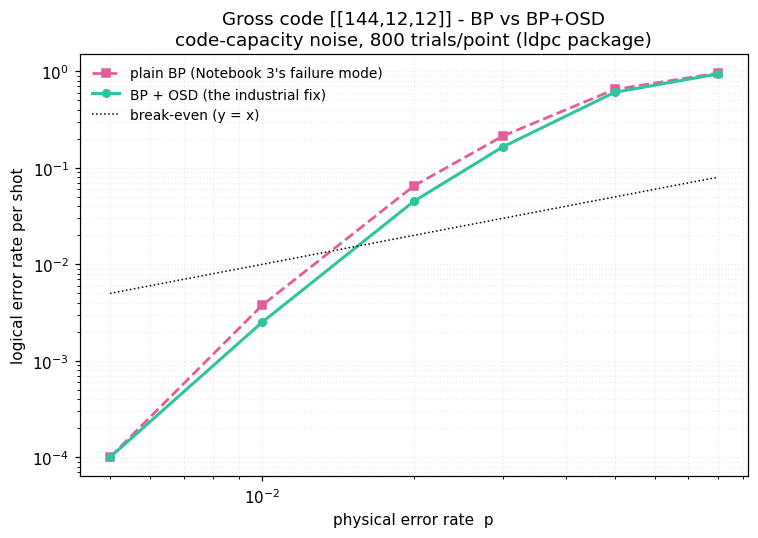

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
floor = 1e-4
ax.loglog(BB_PS, [max(v, floor) for v in bp_curve], "s--", color="#e45d9a",
          label="plain BP (Notebook 3's failure mode)", lw=1.8, ms=5)
ax.loglog(BB_PS, [max(v, floor) for v in osd_curve], "o-", color="#2ec4a0",
          label="BP + OSD (the industrial fix)", lw=2, ms=5)
ax.loglog(BB_PS, BB_PS, "k:", lw=1, label="break-even (y = x)")
ax.set_xlabel("physical error rate  p"); ax.set_ylabel("logical error rate per shot")
ax.set_title("Gross code [[144,12,12]] - BP vs BP+OSD\ncode-capacity noise, "
             f"{TRIALS} trials/point (ldpc package)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", ls=":", color="0.85", alpha=0.5)
plt.tight_layout(); plt.show()

The OSD post-processing step buys a consistent improvement over plain BP at every error rate - and remember from Notebook 3 that plain BP *couldn't even produce a threshold* on the surface code. Degeneracy and short cycles hurt BP on every quantum code; OSD's rank-based cleanup is the standard patch, and this is it running for real, not a diagram of it.

Now the controlled experiment we set up in Section 4: same polynomials, same 12 logical qubits, **half the distance**. If qLDPC codes obey the same threshold physics as the surface code, the bigger code should win at low $p$ and lose above some crossing - the exact fan-out-and-flip signature we measured with Sinter in Notebook 3.

p       [[72,12,6]]  [[144,12,12]]
0.005   0.0013       0.0013
0.01    0.0112       0.0050
0.02    0.0525       0.0400
0.03    0.1388       0.1800
0.05    0.4188       0.5713
0.08    0.7562       0.9237


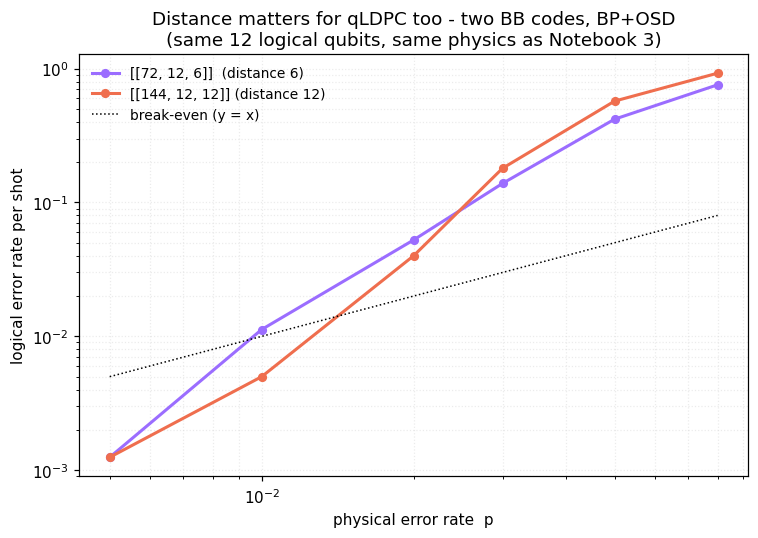

Low p  (p=0.01): distance-12 code better or equal?  True
High p (p=0.08): order flips (bigger code worse)?   True
Same fan-out-and-flip signature the surface code showed in Notebook 3 - on a qLDPC code.


In [9]:
curve72, curve144 = [], []
for p in BB_PS:
    _, dec72  = make_decoders(HZ72, p)
    _, dec144 = make_decoders(HZ,   p)
    curve72.append(logical_error_rate_bb(HX72, HZ72, dec72,  p, TRIALS, seed=200))
    curve144.append(logical_error_rate_bb(HX,   HZ,   dec144, p, TRIALS, seed=200))

print("p       [[72,12,6]]  [[144,12,12]]")
for p, a, b in zip(BB_PS, curve72, curve144):
    print(f"{p:<7} {a:<12.4f} {b:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(BB_PS, [max(v, floor) for v in curve72],  "o-", color="#9b6dff", label="[[72, 12, 6]]  (distance 6)",  lw=2, ms=5)
ax.loglog(BB_PS, [max(v, floor) for v in curve144], "o-", color="#ef6e4e", label="[[144, 12, 12]] (distance 12)", lw=2, ms=5)
ax.loglog(BB_PS, BB_PS, "k:", lw=1, label="break-even (y = x)")
ax.set_xlabel("physical error rate  p"); ax.set_ylabel("logical error rate per shot")
ax.set_title("Distance matters for qLDPC too - two BB codes, BP+OSD\n(same 12 logical qubits, same physics as Notebook 3)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, which="both", ls=":", color="0.85", alpha=0.5)
plt.tight_layout(); plt.show()

low_ok  = curve144[1] <= curve72[1] + 0.005    # p=0.01: bigger distance should win (or tie within noise)
high_ok = curve144[-1] >= curve72[-1] - 0.01   # p=0.08: bigger code should be worse
print(f"Low p  (p={BB_PS[1]}): distance-12 code better or equal?  {low_ok}")
print(f"High p (p={BB_PS[-1]}): order flips (bigger code worse)?   {high_ok}")
print("Same fan-out-and-flip signature the surface code showed in Notebook 3 - on a qLDPC code.")

There's the threshold physics again, on a completely different code family: **below the crossing, doubling the distance suppresses logical errors; above it, the extra qubits are pure liability.** The gross code's advantage is that when it wins, it wins *for 12 logical qubits at once* - that is the ~10x overhead story made concrete.

One honest caveat baked into the numbers: this is **code-capacity** noise. IBM's headline circuit-level results for the gross code (a ~0.7% pseudo-threshold with syndrome-measurement noise included) need the full multi-round circuit treatment, which is a genuine research artifact beyond this notebook. The structural conclusion - BP+OSD decodes BB codes and distance behaves as theory says - is exactly what our simpler noise model can honestly show.

---
## 6 - Honesty: what's real, what's simplified

Keeping faith with the rest of this project. This section used to be a list of things we *didn't* do; the spin-off moved most of them into the "done" column.

**What is real and computed in this notebook:**
- The surface-code $d^2$ overhead scaling (exact for the rotated code we built).
- The **[[144, 12, ...]] gross code and [[72, 12, ...]] BB code, actually constructed** from the published polynomials.
- The **CSS condition $H_X H_Z^T = 0$, verified** by direct GF(2) computation for both codes.
- **$k = 12$ logical qubits, computed** from check-matrix ranks (`ldpc.mod2.rank`), not quoted.
- **Weight-6 checks and degree-6 qubit connectivity, verified** by counting.
- A real **BP+OSD decoder** (Roffe's `ldpc`) run in a Monte Carlo, with the logical-failure test done by rank algebra.

**What is still cited or simplified:**
- The **distances (6 and 12) are cited** from Bravyi et al., not computed - distance computation is a genuinely hard combinatorial problem and no honest notebook-scale shortcut exists.
- The noise model is **code-capacity** (i.i.d. X errors, perfect measurements), not the circuit-level noise of IBM's headline experiment. Notebook 3 showed exactly how much that distinction matters.
- We decode **one error channel** (X errors via $H_Z$); the Z channel is the mirror image by the code's symmetry.
- The "~1,000 physical qubits per logical qubit" surface-code figure remains an illustrative scale, not a single sourced constant.

---
## 7 - Wrap-up - and the bridge to learned decoding

The surface code is the workhorse of today's experiments, but its $d^2$ overhead is a wall at scale. This notebook built the leading alternative *for real*: **bivariate-bicycle codes pack 12 logical qubits into the qubit budget the surface code spends on one**, at the same distance - and we verified the construction ourselves and decoded it with the same BP+OSD stack the research literature uses.

The costs are also now concrete: long-range connectivity (the orange edges), and decoders that need post-processing to survive degeneracy (the BP vs BP+OSD gap). *Harder decoding* is exactly where the last notebook goes:

- **-> Notebook 5 - Learned decoding (GNNs)** - a neural decoder pitted against the classical baselines you've now run.
- **-> [Module 4 - qLDPC Explorer (live)](https://qecexplorer.com/qldpc)** - the interactive gross-code simulation this notebook's math powers.
- **-> [QEC Explorer - research connection](https://qecexplorer.com/research)** - how these threads connect to current research.

You've now seen both halves of the scaling problem - **better codes** (this notebook, built and decoded) and **better decoders** (next). That's the frontier.

---
### Citations
- S. Bravyi, A. Cross, J. Gambetta, D. Maslov, P. Rall, T. Yoder, **"High-threshold and low-overhead fault-tolerant quantum memory,"** *Nature* 627, 778-782 (2024). The bivariate-bicycle construction, the polynomials for the [[144,12,12]] gross code and [[72,12,6]] code, and the cited distances.
- J. Roffe, D. R. White, S. Burton, E. Campbell, **"Decoding across the quantum low-density parity-check code landscape,"** *Phys. Rev. Research* 2, 043423 (2020), and J. Roffe, **LDPC: Python tools for low density parity check codes** (2022), github.com/quantumgizmos/ldpc (MIT). The BP+OSD decoder used here.
- The Error Correction Zoo, **"Bivariate bicycle (BB) code"** entry (errorcorrectionzoo.org) - weight-6 checks, planar-layer connectivity, code parameters.
- IBM Quantum blog - the ~10x overhead-reduction figure and the fault-tolerance roadmap.
- Surface-code $d^2$ overhead is structural to the rotated surface code built in Notebook 1; the "~1000 physical : 1 logical" figure is illustrative of commonly-cited scales, not a single sourced constant.